# Music Listener Segmentation

Topic: play counts -> normalize/rank -> t-SNE -> K-Means -> silhouette score -> music taste segments.


## 1. Import libraries


In [1]:
import io
import json
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import GridSearchCV
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_style("whitegrid")

OUTPUT_DIR = Path("E:/GNPICIL/WEEK 4")
CHART_DIR = OUTPUT_DIR / "charts"
CHART_DIR.mkdir(parents=True, exist_ok=True)


## 2. Load Last.fm play-count data


In [2]:
url = "https://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip"

data = urllib.request.urlopen(url).read()
zip_file = zipfile.ZipFile(io.BytesIO(data))

user_artists = pd.read_csv(zip_file.open("user_artists.dat"), sep="\t")
artists = pd.read_csv(zip_file.open("artists.dat"), sep="\t")

print(user_artists.shape)
user_artists.head()


(92834, 3)


,userID,artistID,weight
0,2,51,13883
1,2,52,11690
2,2,53,11351
3,2,54,10300
4,2,55,8983


In [3]:
artists.head()


,id,name,url,pictureURL
0,1,MALICE MIZER,http://www.last.fm/music/MALICE+MIZER,http://userserve-ak.last.fm/serve/252/10808.jpg
1,2,Diary of Dreams,http://www.last.fm/music/Diary+of+Dreams,http://userserve-ak.last.fm/serve/252/3052066.jpg
2,3,Carpathian Forest,http://www.last.fm/music/Carpathian+Forest,http://userserve-ak.last.fm/serve/252/40222717...
3,4,Moi dix Mois,http://www.last.fm/music/Moi+dix+Mois,http://userserve-ak.last.fm/serve/252/54697835...
4,5,Bella Morte,http://www.last.fm/music/Bella+Morte,http://userserve-ak.last.fm/serve/252/14789013...


## 3. Prepare data


In [4]:
# Select top 12 artists by total play count
top_artist_ids = (
    user_artists.groupby("artistID")["weight"]
    .sum()
    .sort_values(ascending=False)
    .head(12)
    .index
)

artist_names = artists.set_index("id")["name"].to_dict()
top_artist_names = [artist_names[i] for i in top_artist_ids]

# Create one row per listener and one column per artist
music_data = user_artists[user_artists["artistID"].isin(top_artist_ids)]
play_counts = music_data.pivot_table(
    index="userID",
    columns="artistID",
    values="weight",
    aggfunc="sum",
    fill_value=0
)
play_counts = play_counts[top_artist_ids]
play_counts.columns = top_artist_names

print(play_counts.shape)
play_counts.head()


(1381, 12)


,Britney Spears,Depeche Mode,Lady Gaga,Christina Aguilera,Paramore,Madonna,Rihanna,Shakira,The Beatles,Katy Perry,Avril Lavigne,Taylor Swift
userID,,,,,,,,,,,,
2,0,2619,1519,0,0,3301,0,0,0,0,0,0
4,0,4983,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,138,0,0,0
7,11112,0,5846,4201,0,2540,43864,0,0,1747,498,0
8,2258,0,921,783,0,0,428,0,0,347,0,553


In [5]:
# Normalize and rank the play counts
log_counts = np.log1p(play_counts)
ranked_data = log_counts.rank(axis=1, pct=True)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(ranked_data)

scaled_df = pd.DataFrame(scaled_data, columns=play_counts.columns, index=play_counts.index)
scaled_df.head()


,Britney Spears,Depeche Mode,Lady Gaga,Christina Aguilera,Paramore,Madonna,Rihanna,Shakira,The Beatles,Katy Perry,Avril Lavigne,Taylor Swift
userID,,,,,,,,,,,,
2,-0.915854,1.606034,0.956573,-0.685181,-0.479587,2.220500,-0.832997,-0.438945,-0.482568,-0.787645,-0.578243,-0.318046
4,-0.528948,1.922114,-0.596891,-0.226066,-0.116379,-0.180683,-0.373125,0.096789,-0.207753,-0.295233,-0.123227,0.167014
5,-0.528948,0.025634,-0.596891,-0.226066,-0.116379,-0.180683,-0.373125,0.096789,1.441137,-0.295233,-0.123227,0.167014
7,1.405580,-0.922606,0.956573,1.151276,-1.206003,0.619711,2.386104,-1.510411,-1.032198,0.197179,-0.123227,-1.288166
8,1.792485,-0.764566,1.344939,1.610391,-1.024399,-1.181176,0.546618,-1.242545,-0.894790,0.197179,-1.260767,1.622193


## 4. EDA and preprocessing checks


In [6]:
summary_stats = play_counts.describe().T[["mean", "std", "min", "50%", "max"]]
summary_stats


,mean,std,min,50%,max
Britney Spears,1732.903693,7819.318081,0.0,0.0,131733.0
Depeche Mode,942.293990,10850.579341,0.0,0.0,352698.0
Lady Gaga,935.110065,4467.559348,0.0,0.0,114672.0
Christina Aguilera,766.404779,5645.130903,0.0,0.0,176133.0
Paramore,697.645909,7138.331645,0.0,0.0,227829.0
Madonna,667.051412,3013.529174,0.0,0.0,41216.0
Rihanna,655.628530,3083.622420,0.0,0.0,43864.0
Shakira,498.572773,6751.511433,0.0,0.0,172496.0
The Beatles,479.446778,1961.051403,0.0,0.0,29856.0
Katy Perry,385.622737,1682.427498,0.0,0.0,37585.0


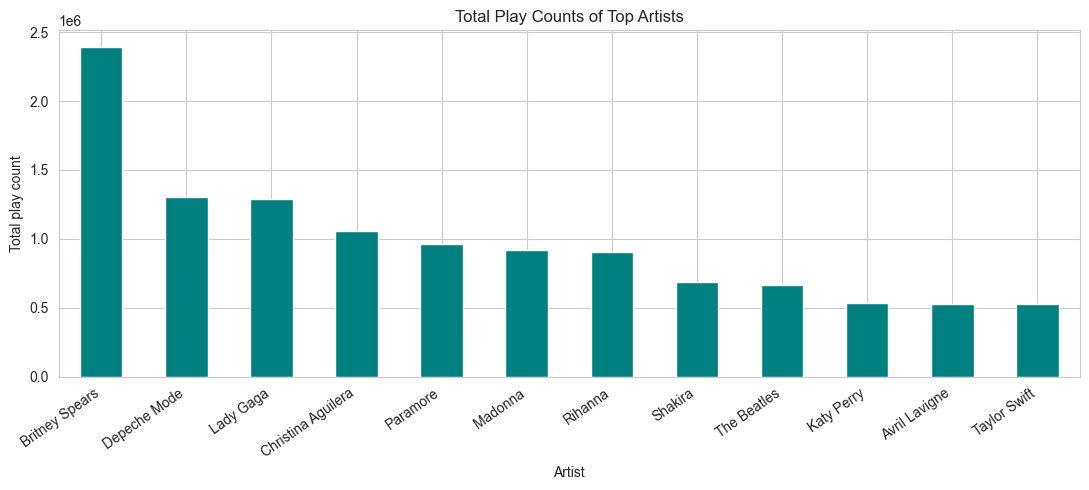

In [7]:
artist_totals = play_counts.sum().sort_values(ascending=False)

plt.figure(figsize=(11, 5))
artist_totals.plot(kind="bar", color="teal")
plt.title("Total Play Counts of Top Artists")
plt.xlabel("Artist")
plt.ylabel("Total play count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "01_artist_play_counts.png", dpi=160)
plt.show()


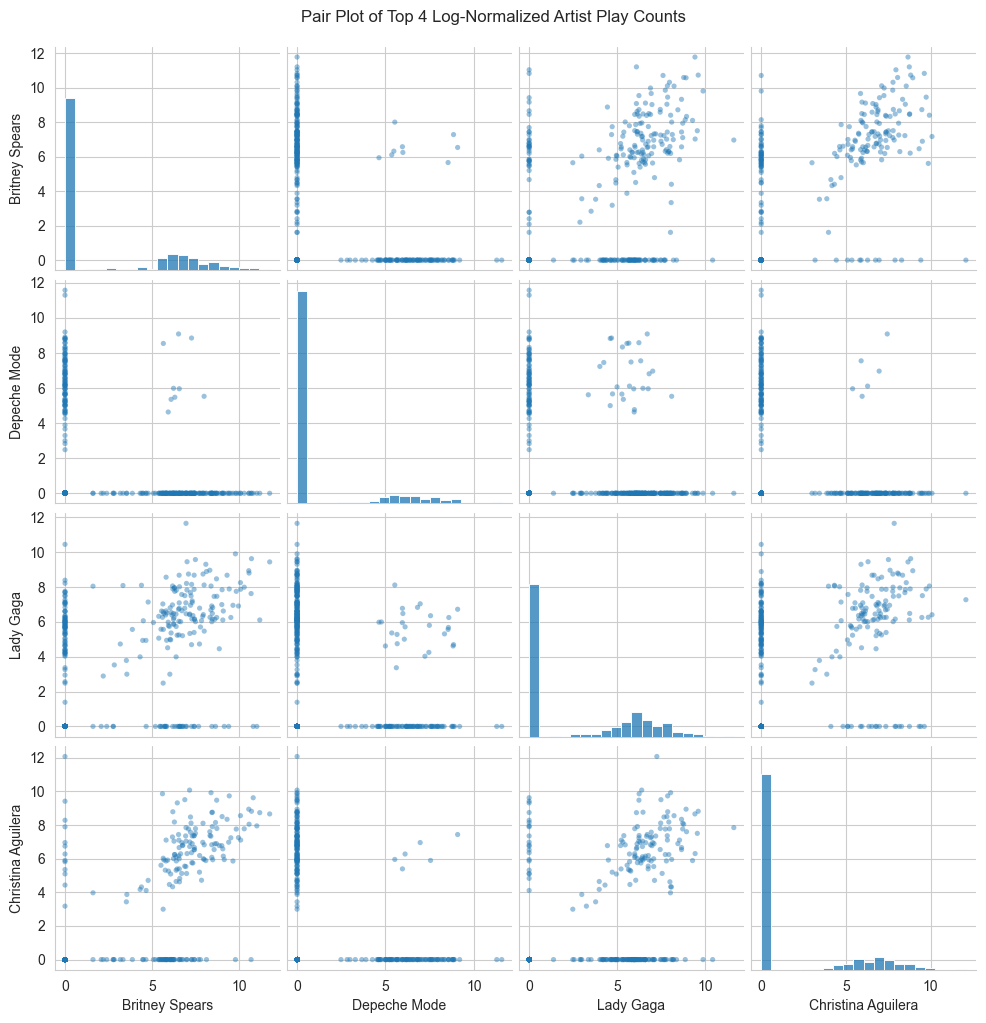

In [8]:
pairplot_data = log_counts[top_artist_names[:4]].sample(
    n=min(500, len(log_counts)),
    random_state=42
)

sns.pairplot(
    pairplot_data,
    diag_kind="hist",
    plot_kws={"s": 14, "alpha": 0.45, "edgecolor": "none"},
    diag_kws={"bins": 20}
)
plt.suptitle("Pair Plot of Top 4 Log-Normalized Artist Play Counts", y=1.02)
plt.savefig(CHART_DIR / "02_pairplot.png", dpi=160, bbox_inches="tight")
plt.show()


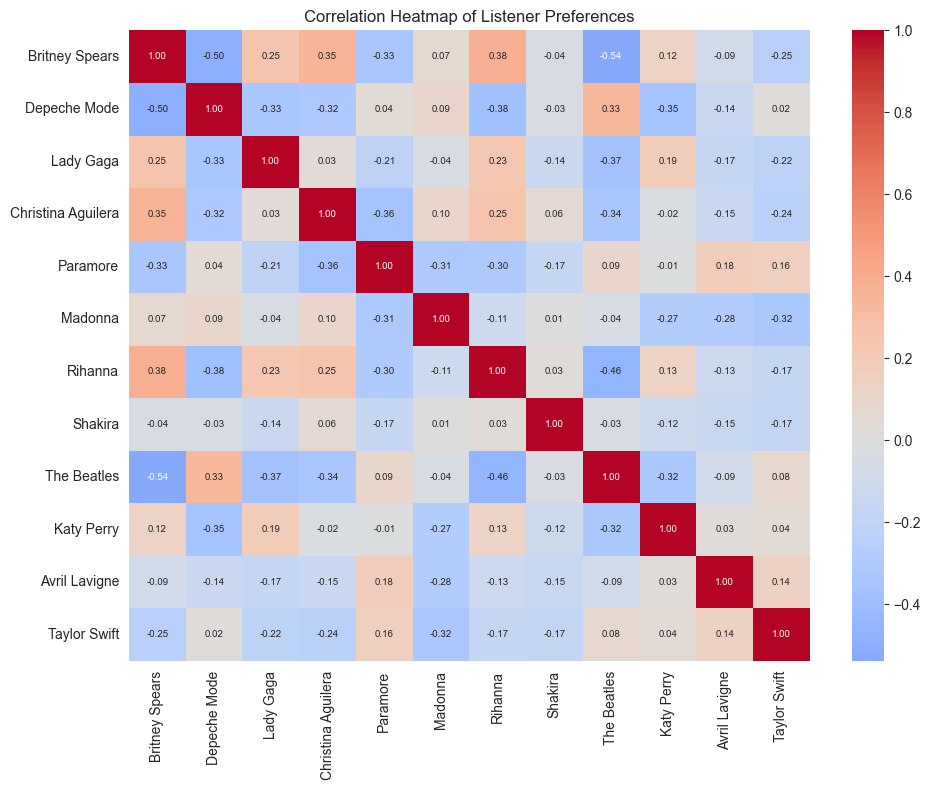

In [9]:
corr = ranked_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlation Heatmap of Listener Preferences")
plt.tight_layout()
plt.savefig(CHART_DIR / "03_correlation_heatmap_numbers.png", dpi=180)
plt.show()


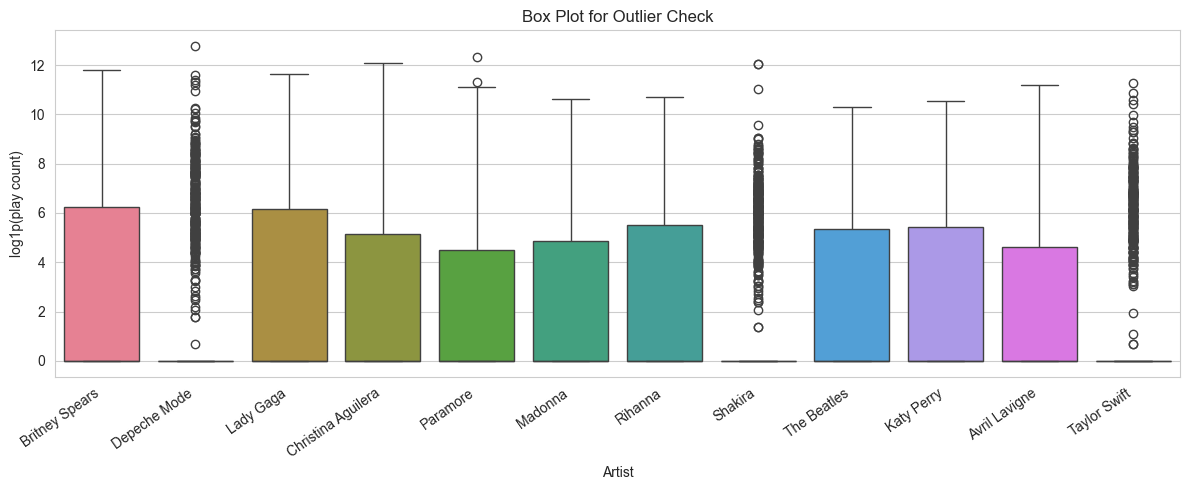

In [10]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=log_counts)
plt.title("Box Plot for Outlier Check")
plt.xlabel("Artist")
plt.ylabel("log1p(play count)")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.savefig(CHART_DIR / "04_boxplot_outliers.png", dpi=160)
plt.show()


## 5. Dimensionality reduction


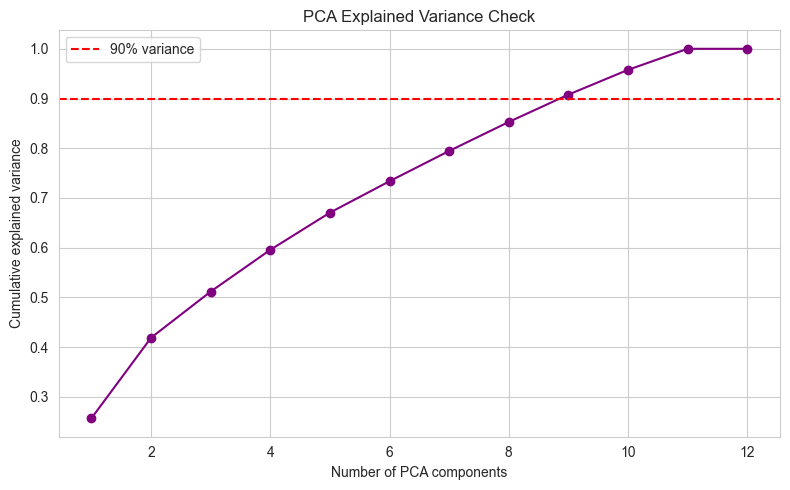

In [11]:
pca = PCA()
pca.fit(scaled_df)

explained_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o", color="purple")
plt.axhline(0.90, color="red", linestyle="--", label="90% variance")
plt.title("PCA Explained Variance Check")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "05_pca_variance.png", dpi=160)
plt.show()


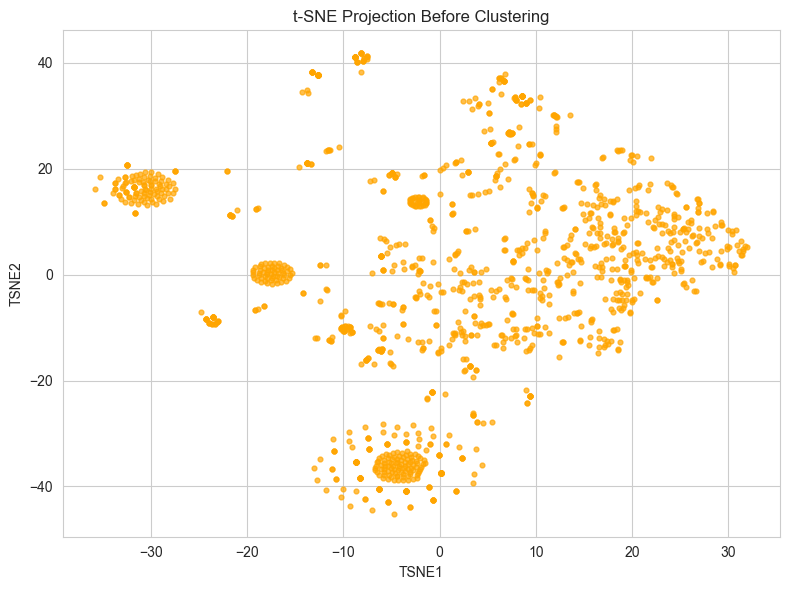

In [12]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42,
    max_iter=1000
)

tsne_values = tsne.fit_transform(scaled_df)
tsne_df = pd.DataFrame(tsne_values, columns=["TSNE1", "TSNE2"], index=play_counts.index)

plt.figure(figsize=(8, 6))
plt.scatter(tsne_df["TSNE1"], tsne_df["TSNE2"], s=12, color="orange", alpha=0.7)
plt.title("t-SNE Projection Before Clustering")
plt.xlabel("TSNE1")
plt.ylabel("TSNE2")
plt.tight_layout()
plt.savefig(CHART_DIR / "06_tsne_before_clustering.png", dpi=160)
plt.show()


## 6. Choose K and tune K-Means


In [13]:
wcss = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(tsne_df)
    wcss.append(model.inertia_)
    silhouette_scores.append(silhouette_score(tsne_df, labels))

result_table = pd.DataFrame({
    "k": list(k_values),
    "WCSS": wcss,
    "Silhouette Score": silhouette_scores
})

result_table


,k,WCSS,Silhouette Score
0,2,539250.125000,0.397250
1,3,312568.343750,0.450345
2,4,205469.593750,0.484434
3,5,138680.843750,0.495285
4,6,108975.046875,0.496376
5,7,88918.632812,0.506498
6,8,74300.726562,0.525011


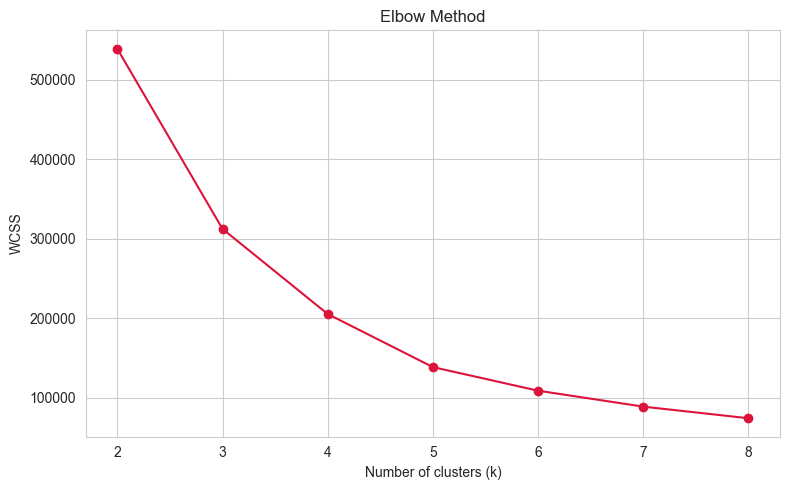

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), wcss, marker="o", color="crimson")
plt.title("Elbow Method")
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.tight_layout()
plt.savefig(CHART_DIR / "07_elbow_method.png", dpi=160)
plt.show()


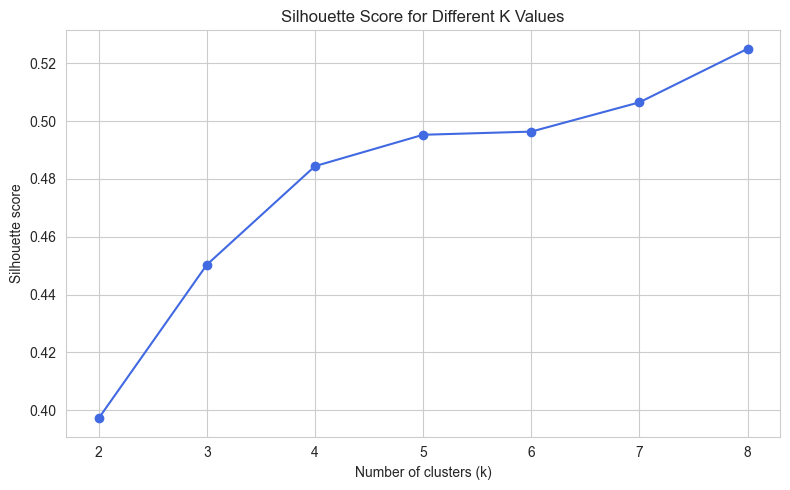

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_values), silhouette_scores, marker="o", color="royalblue")
plt.title("Silhouette Score for Different K Values")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.tight_layout()
plt.savefig(CHART_DIR / "08_silhouette_scores.png", dpi=160)
plt.show()


In [16]:
# GridSearchCV tuning, kept small and simple
def silhouette_scorer(model, X, y=None):
    labels = model.predict(X)
    unique_labels = set(labels)
    if len(unique_labels) < 2 or len(unique_labels) >= len(labels):
        return -1
    return silhouette_score(X, labels)

grid = GridSearchCV(
    KMeans(random_state=42, n_init=10),
    param_grid={"n_clusters": list(k_values), "init": ["k-means++", "random"]},
    scoring=silhouette_scorer,
    cv=3
)

grid.fit(tsne_df)

print("Best parameters:", grid.best_params_)
print("Best GridSearchCV score:", round(grid.best_score_, 3))


Best parameters: {'init': 'random', 'n_clusters': 8}
Best GridSearchCV score: 0.512


## 7. Final clustering


In [17]:
best_k = grid.best_params_["n_clusters"]

kmeans = KMeans(
    n_clusters=best_k,
    init=grid.best_params_["init"],
    random_state=42,
    n_init=10
)
clusters = kmeans.fit_predict(tsne_df)

tsne_df["Cluster"] = clusters
model_data = play_counts.copy()
model_data["Cluster"] = clusters

final_score = silhouette_score(tsne_df[["TSNE1", "TSNE2"]], clusters)
db_score = davies_bouldin_score(tsne_df[["TSNE1", "TSNE2"]], clusters)

print("Best k:", best_k)
print("Final silhouette score:", round(final_score, 3))
print("Davies-Bouldin score:", round(db_score, 3))


Best k: 8
Final silhouette score: 0.525
Davies-Bouldin score: 0.657


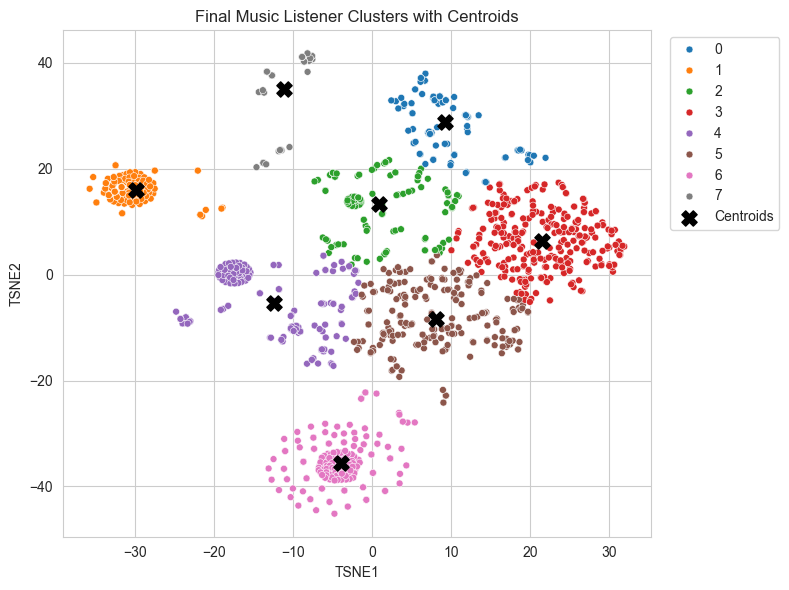

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Cluster",
    palette="tab10",
    s=25
)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c="black", s=120, marker="X", label="Centroids")
plt.title("Final Music Listener Clusters with Centroids")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(CHART_DIR / "09_final_tsne_clusters_centroids.png", dpi=160)
plt.show()


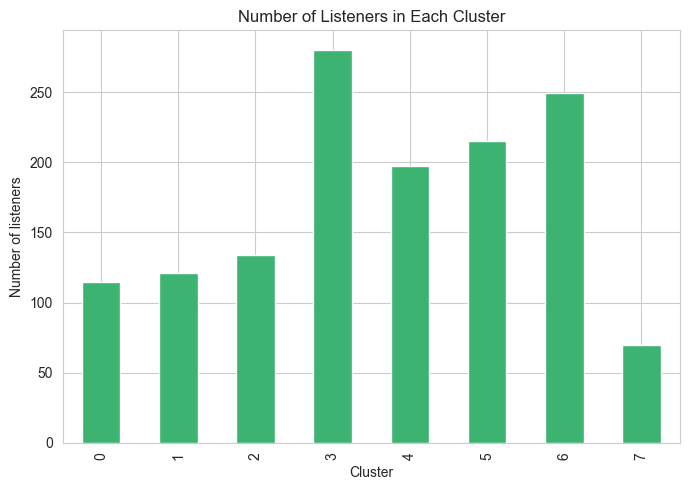

In [19]:
cluster_sizes = model_data["Cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
cluster_sizes.plot(kind="bar", color="mediumseagreen")
plt.title("Number of Listeners in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of listeners")
plt.tight_layout()
plt.savefig(CHART_DIR / "10_cluster_sizes.png", dpi=160)
plt.show()


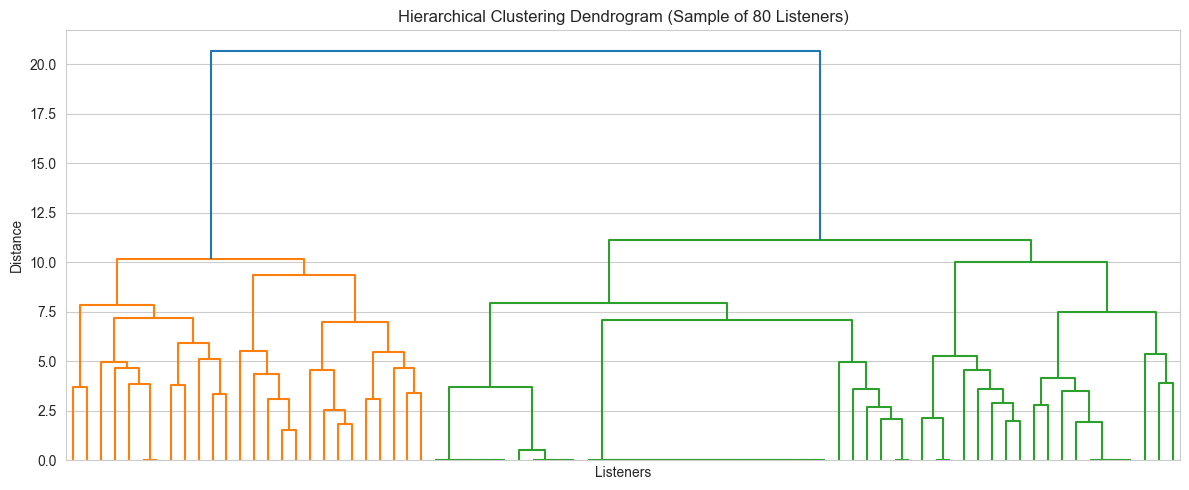

In [20]:
# Dendrogram on a small sample, so the graph stays readable
sample_for_dendrogram = scaled_df.sample(80, random_state=42)
linked = linkage(sample_for_dendrogram, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(linked, no_labels=True)
plt.title("Hierarchical Clustering Dendrogram (Sample of 80 Listeners)")
plt.xlabel("Listeners")
plt.ylabel("Distance")
plt.tight_layout()
plt.savefig(CHART_DIR / "11_dendrogram.png", dpi=160)
plt.show()


## 8. Music taste segments


In [21]:
cluster_profiles = model_data.groupby("Cluster")[top_artist_names].mean()
cluster_profiles


,Britney Spears,Depeche Mode,Lady Gaga,Christina Aguilera,Paramore,Madonna,Rihanna,Shakira,The Beatles,Katy Perry,Avril Lavigne,Taylor Swift
Cluster,,,,,,,,,,,,
0,293.730435,3914.426087,362.626087,223.713043,21.252174,1141.426087,137.095652,17.565217,471.347826,28.834783,11.565217,22.878261
1,0.000000,5716.000000,9.735537,0.000000,18.363636,0.000000,5.842975,6.892562,0.000000,0.000000,0.504132,0.330579
2,811.201493,18.231343,1213.223881,522.776119,823.059701,546.559701,220.059701,78.656716,477.291045,176.380597,110.201493,49.477612
3,5986.964286,22.353571,2696.428571,2781.507143,141.696429,2461.378571,2150.696429,2165.696429,20.875000,940.346429,405.117857,103.189286
4,28.908629,6.548223,445.040609,15.847716,2743.573604,11.700508,17.000000,61.690355,582.416244,118.197970,373.355330,20.928934
5,2017.213953,14.093023,1105.032558,823.097674,1242.920930,113.088372,1177.702326,257.362791,94.404651,1016.758140,1495.972093,2246.395349
6,541.823293,11.538153,1.148594,14.923695,0.000000,2.417671,2.602410,5.036145,1337.072289,0.000000,3.791165,0.000000
7,0.000000,2051.685714,77.057143,0.000000,15.800000,4.114286,0.914286,0.000000,1002.071429,5.842857,1.771429,0.000000


<Figure size 1300x600 with 0 Axes>

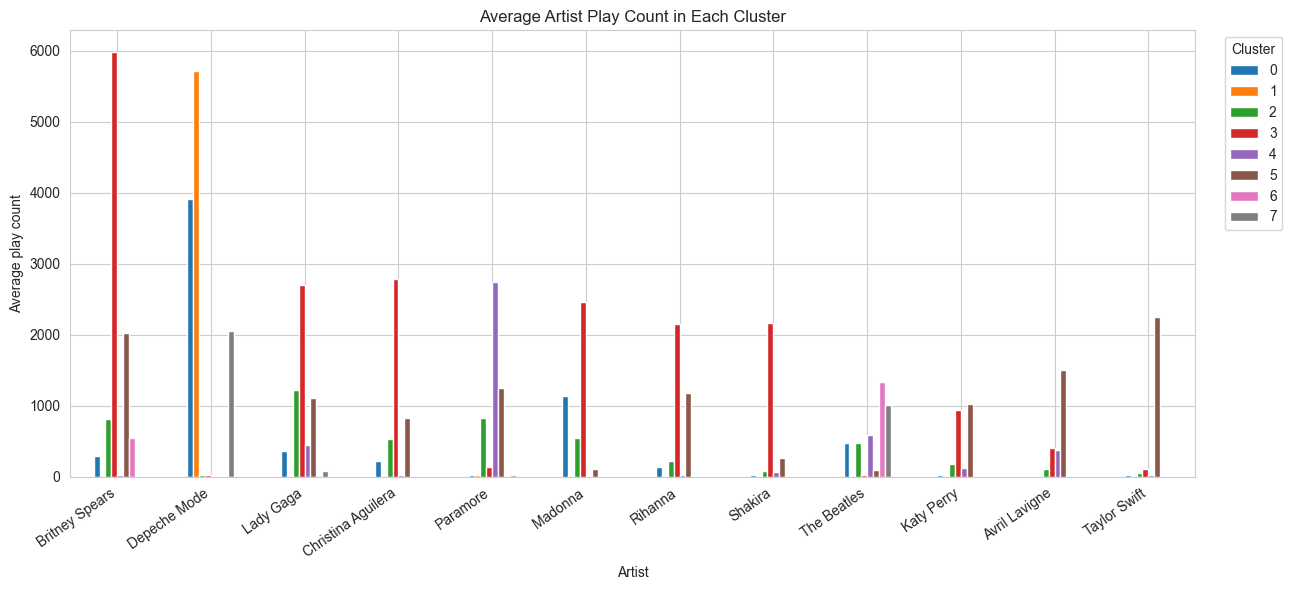

In [22]:
plt.figure(figsize=(13, 6))
cluster_profiles.T.plot(kind="bar", figsize=(13, 6))
plt.title("Average Artist Play Count in Each Cluster")
plt.xlabel("Artist")
plt.ylabel("Average play count")
plt.xticks(rotation=35, ha="right")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(CHART_DIR / "12_cluster_profiles.png", dpi=160)
plt.show()


In [23]:
segment_names = {}

for cluster_number in cluster_profiles.index:
    top_two_artists = cluster_profiles.loc[cluster_number].sort_values(ascending=False).head(2).index
    segment_names[cluster_number] = f"{top_two_artists[0]} / {top_two_artists[1]} listeners"

segment_summary = pd.DataFrame({
    "Cluster": list(segment_names.keys()),
    "Music Taste Segment": list(segment_names.values()),
    "Listeners": [cluster_sizes[c] for c in segment_names.keys()]
})

segment_summary


,Cluster,Music Taste Segment,Listeners
0,0,Depeche Mode / Madonna listeners,115
1,1,Depeche Mode / Paramore listeners,121
2,2,Lady Gaga / Paramore listeners,134
3,3,Britney Spears / Christina Aguilera listeners,280
4,4,Paramore / The Beatles listeners,197
5,5,Taylor Swift / Britney Spears listeners,215
6,6,The Beatles / Britney Spears listeners,249
7,7,Depeche Mode / The Beatles listeners,70


## 9. Save final outputs


In [24]:
segment_summary.to_csv(OUTPUT_DIR / "music_listener_segment_summary.csv", index=False)
cluster_profiles.to_csv(OUTPUT_DIR / "music_listener_cluster_profiles.csv")
summary_stats.to_csv(OUTPUT_DIR / "music_listener_summary_statistics.csv")

results = {
    "listeners": int(play_counts.shape[0]),
    "artists": len(top_artist_names),
    "best_k": int(best_k),
    "best_params": grid.best_params_,
    "silhouette_score": float(final_score),
    "davies_bouldin_score": float(db_score),
    "top_artists": top_artist_names,
    "cluster_sizes": {str(k): int(v) for k, v in cluster_sizes.items()},
    "segments": {
        str(row["Cluster"]): {
            "label": row["Music Taste Segment"],
            "listeners": int(row["Listeners"])
        }
        for _, row in segment_summary.iterrows()
    },
        "project_requirements_implemented": [
        "summary statistics",
        "pair plot",
        "numeric heatmap",
        "outlier box plot",
        "PCA variance check",
        "t-SNE projection",
        "K-Means clustering",
        "GridSearchCV tuning",
        "silhouette score",
        "Davies-Bouldin score",
        "cluster centroids",
        "dendrogram",
        "cluster labels",
        "final reporting outputs"
    ],
    "charts": {
        "artist_play_counts": "charts/01_artist_play_counts.png",
        "pairplot": "charts/02_pairplot.png",
        "correlation_heatmap_numbers": "charts/03_correlation_heatmap_numbers.png",
        "boxplot_outliers": "charts/04_boxplot_outliers.png",
        "pca_variance": "charts/05_pca_variance.png",
        "tsne_before": "charts/06_tsne_before_clustering.png",
        "elbow_method": "charts/07_elbow_method.png",
        "silhouette_scores": "charts/08_silhouette_scores.png",
        "final_clusters_centroids": "charts/09_final_tsne_clusters_centroids.png",
        "cluster_sizes": "charts/10_cluster_sizes.png",
        "dendrogram": "charts/11_dendrogram.png",
        "cluster_profiles": "charts/12_cluster_profiles.png"
    }
}

with open(OUTPUT_DIR / "music_listener_results.json", "w") as f:
    json.dump(results, f, indent=2)

print("Files saved in:", OUTPUT_DIR)


Files saved in: E:\GNPICIL\WEEK 4


## Conclusion

The project now covers the main project requirements and the exact Music Listener Segmentation topic row.
